In [2]:
import os
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Homography mapping of Top → Side cameras with RANSAC
Let's estimate a **planar mapping** between the Top camera and each Side camera using a **homography**. A homography is a 3×3 projective transform \(H\) that maps 2D points on the same physical plane between two camera views:

$$
\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} \sim
H \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}
$$

#### Why RANSAC?
SLEAP labelling occasionally contain outliers (mislocalized corners, brief occlusions, motion blur). Fitting \(H\) directly to all correspondences can fail. **RANSAC** makes the fit robust by repeatedly:
1. Sampling a minimal set of 4 point correspondences,
2. Fitting a candidate homography,
3. Counting **inliers** (pairs whose reprojection error is below a pixel threshold),
4. Keeping the model with the most inliers, then refitting using all inliers.

#### Inputs to RANSAC
We use matched high-quality frames where **all 4 card corners** are present in both cameras and have confidence ≥ a chosen threshold (used 0.85 confidence). For each camera pair we build:
- `top_pts`: shape `(N, 4, 2)`
- `side_pts`: shape `(N, 4, 2)`
These are reshaped into a single list of point pairs `(4N, 2)` for homography estimation.

#### Output
For each Side camera we obtain a homography \(H_{top\rightarrow side}\) plus an inlier mask and basic fit diagnostics (inlier count, reprojection error).

#### Metadata

In [ ]:
experiment = "abcEphysPilot01"
arena = "AEON3"
session = "2026-04-14T141851Z_calibrateBeforeAprilExperiments"
chunk = "2026-04-14T14-00-00"

OUT_DIR = Path(f"/Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/{experiment}")
MAP_PATH = OUT_DIR / "mapping_top_to_sides_minScore0.85.npz"
assert MAP_PATH.exists(), f"Missing: {MAP_PATH}"

### Homography params

In [4]:
ransac_reproj_threshold_px = 5.0   # typical: 2-10 px; increase if detections are noisy
ransac_confidence = 0.995
ransac_max_iters = 5000

# Cameras expected inside the saved npz (based on your earlier naming convention)
side_cameras = ["CameraNorth", "CameraSouth", "CameraEast", "CameraWest"]

#### Load .npz file with card mappings

In [5]:
z = np.load(MAP_PATH)

# Quick peek
keys = sorted(list(z.keys()))
print("Keys in npz (first 20):")
print(keys[:20])
print("\nTotal keys:", len(keys))

Keys in npz (first 20):
['CameraEast__frames', 'CameraEast__side_pts', 'CameraEast__top_pts', 'CameraNorth__frames', 'CameraNorth__side_pts', 'CameraNorth__top_pts', 'CameraSouth__frames', 'CameraSouth__side_pts', 'CameraSouth__top_pts', 'CameraWest__frames', 'CameraWest__side_pts', 'CameraWest__top_pts']

Total keys: 12


## Helper fun

In [6]:
def stack_corner_points(arr: np.ndarray) -> np.ndarray:
    """
    Convert (N,4,2) -> (4N,2).
    Each frame contributes 4 corner correspondences.
    """
    re_arr = np.asarray(arr, dtype=np.float32)
    assert re_arr.ndim == 3 and re_arr.shape[1:] == (4, 2), f"Expected (N,4,2), got {re_arr.shape}" # check if for sure that shape
    return re_arr.reshape(-1, 2)

def apply_homography(H: np.ndarray, xy: np.ndarray) -> np.ndarray:
    """
    Apply 3x3 homography H to points xy of shape (M,2).
    Returns projected points (M,2).
    """
    xy = np.asarray(xy, dtype=np.float64)
    ones = np.ones((xy.shape[0], 1), dtype=np.float64)
    X = np.concatenate([xy, ones], axis=1)  # (M,3) so each row is [x, y, 1]
    Y = (H @ X.T).T                         # X.T is (3, M), and we apply the H matrix to every point, then return [u, v, w]
    y = Y[:, :2] / Y[:, 2:3]                # obtain [u, v] and [w] and divide by w: dehomogenization
    return y

def reprojection_errors_px(H: np.ndarray, src_xy: np.ndarray, dst_xy: np.ndarray) -> np.ndarray:
    """
    Pixel reprojection error per correspondence -> Euclidean distance between projections
    """
    pred = apply_homography(H, src_xy) # this is the predicted dst_xy
    return np.linalg.norm(pred - np.asarray(dst_xy, dtype=np.float64), axis=1)

## RANSAC

In [7]:
rows = []
H_by_cam = {}
inliers_by_cam = {}

for cam in side_cameras:
    frames_key = f"{cam}__frames"
    top_key = f"{cam}__top_pts"
    side_key = f"{cam}__side_pts"

    if frames_key not in z or top_key not in z or side_key not in z: # check file content for the camera of intrest 
        print(f"Skipping {cam}: missing keys in npz.")
        continue
    
    # unpack data
    frames = z[frames_key]
    top_pts = z[top_key]     # (N,4,2)
    side_pts = z[side_key]   # (N,4,2)
    
    src = stack_corner_points(top_pts)   # Top points, shape (4N,2)
    dst = stack_corner_points(side_pts)  # Side points, shape (4N,2)

    if src.shape[0] < 4:  # for very low point amounts check
        print(f"Skipping {cam}: not enough correspondences ({src.shape[0]}).")
        continue

    # Fit homography with RANSAC
    H, inlier_mask = cv2.findHomography(
        src, dst,
        method=cv2.RANSAC,
        ransacReprojThreshold=ransac_reproj_threshold_px,
        maxIters=ransac_max_iters,
        confidence=ransac_confidence,
    )

    if H is None or inlier_mask is None:
        print(f"Failed to fit homography for {cam}.")
        continue

    inlier_mask = inlier_mask.ravel().astype(bool)
    errs = reprojection_errors_px(H, src, dst)

    n_total = src.shape[0]
    n_in = int(inlier_mask.sum())
    frac_in = n_in / n_total if n_total else np.nan

    rows.append({
        "camera": cam,
        "n_frames_used": int(top_pts.shape[0]),
        "n_correspondences": int(n_total),
        "n_inliers": n_in,
        "inlier_frac": frac_in,
        "median_err_px_all": float(np.median(errs)),
        "median_err_px_inliers": float(np.median(errs[inlier_mask])) if n_in else np.nan,
        "mean_err_px_inliers": float(np.mean(errs[inlier_mask])) if n_in else np.nan,
        "ransac_thresh_px": float(ransac_reproj_threshold_px),
    })

    H_by_cam[cam] = H
    inliers_by_cam[cam] = inlier_mask

summary_df = pd.DataFrame(rows).sort_values("camera")
display(summary_df)

,camera,n_frames_used,n_correspondences,n_inliers,inlier_frac,median_err_px_all,median_err_px_inliers,mean_err_px_inliers,ransac_thresh_px
2,CameraEast,2281,9124,3165,0.346887,9.222850,2.809144,2.797107,5.0
0,CameraNorth,1897,7588,3387,0.446363,5.622073,2.372335,2.571399,5.0
1,CameraSouth,1039,4156,2277,0.547883,4.280393,2.493302,2.477923,5.0
3,CameraWest,1767,7068,2876,0.406904,6.411124,2.657158,2.735012,5.0


## Reprojection error sanity check

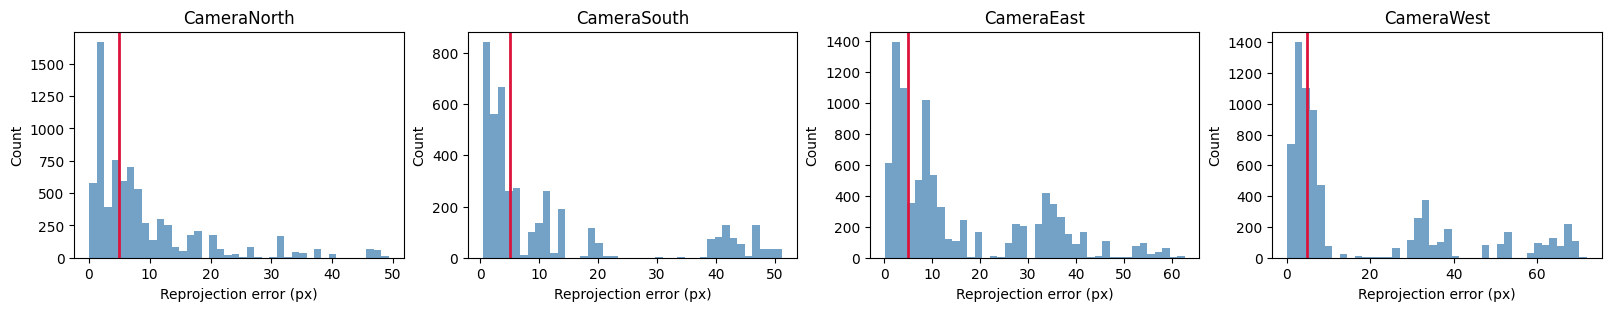

In [8]:
fig, axes = plt.subplots(1, len(H_by_cam), figsize=(4 * len(H_by_cam), 3), constrained_layout=True)
if len(H_by_cam) == 1:
    axes = [axes]

for ax, (cam, H) in zip(axes, H_by_cam.items()):
    src = stack_corner_points(z[f"{cam}__top_pts"])
    dst = stack_corner_points(z[f"{cam}__side_pts"])
    inlier_mask = inliers_by_cam[cam]
    errs = reprojection_errors_px(H, src, dst)

    ax.hist(errs, bins=40, alpha=0.75, color="steelblue")
    ax.axvline(ransac_reproj_threshold_px, color="crimson", linewidth=2, label="RANSAC thresh")
    ax.set_title(cam)
    ax.set_xlabel("Reprojection error (px)")
    ax.set_ylabel("Count")

plt.show()

#### **What the number means:** for each matched corner correspondence, you take the **Top** corner point, map it into the **Side** image using the fitted homography **H**, and measure the pixel distance to where SLEAP actually predicted that corner in the Side image -> the lower the better

## Save homography matrices

In [10]:
H_save_path = out_dir / f"homographies_top_to_sides_ransac_thresh{ransac_reproj_threshold_px:.1f}px.npz"
np.savez_compressed(
    H_save_path,
    **{f"{cam}__H_top_to_side": H for cam, H in H_by_cam.items()}
)
print("Saved homographies:", H_save_path)

# Save the summary table
summary_csv_path = out_dir / f"homography_fit_summary_thresh{ransac_reproj_threshold_px:.1f}px.csv"
summary_df.to_csv(summary_csv_path, index=False)
print("Saved fit summary:", summary_csv_path)

Saved homographies: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/homographies_top_to_sides_ransac_thresh5.0px.npz
Saved fit summary: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/homography_fit_summary_thresh5.0px.csv


## Visual sanity check

In [20]:
# helper functions for frame transformation
def read_frame(video_path: str | Path, frame_idx: int) -> np.ndarray:
    """Read one BGR frame from a video at frame_idx."""
    video_path = str(video_path)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        raise FileNotFoundError(f"Could not open video: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok or frame is None:
        raise RuntimeError(f"Could not read frame {frame_idx} from: {video_path}")
    return frame  # BGR

def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def overlay_side_on_top(top_bgr: np.ndarray, side_bgr: np.ndarray, H_top_to_side: np.ndarray, alpha: float):
    """
    Returns:
      - overlay_rgb: Top + warped(Side) blended in Top coordinates
      - warped_side_rgb: Side warped into Top coordinates
      - H_side_to_top: inverse homography used for warping
    """
    H_side_to_top = np.linalg.inv(H_top_to_side)
    top_h, top_w = top_bgr.shape[:2]
    warped_side_bgr = cv2.warpPerspective(side_bgr, H_side_to_top, (top_w, top_h))
    top_rgb = bgr_to_rgb(top_bgr)
    side_rgb = bgr_to_rgb(side_bgr)
    warped_side_rgb = bgr_to_rgb(warped_side_bgr)
    overlay_rgb = cv2.addWeighted(top_rgb, 1 - alpha, warped_side_rgb, alpha, 0)
    return overlay_rgb, warped_side_rgb, top_rgb, side_rgb, H_side_to_top


In [21]:
# file retrieval
def build_video_path(raw_video_root: Path, arena: str, experiment: str, session: str, chunk: str, camera: str) -> Path:
    return raw_video_root / arena / experiment / session / camera / f"{camera}_{chunk}.avi"

def load_npz_pair(out_dir: Path, corr_name: str, H_glob: str):
    corr_npz = out_dir / corr_name
    H_npz = next(out_dir.glob(H_glob))
    z_corr = np.load(corr_npz)
    z_H = np.load(H_npz)
    print("Loaded correspondences:", corr_npz)
    print("Loaded homographies:", H_npz)
    return z_corr, z_H, corr_npz, H_npz

In [22]:
# plotting helper functions
def draw_corner_viz(overlay_rgb: np.ndarray, top4_xy: np.ndarray, side4_xy_warped: np.ndarray):
    """
    Draws:
      - green circles: Top corners
      - red circles: Side corners warped into Top coords
    """
    viz = overlay_rgb.copy()
    for (x, y) in top4_xy:
        cv2.circle(viz, (int(x), int(y)), 6, (0, 255, 0), -1)
    for (x, y) in side4_xy_warped:
        cv2.circle(viz, (int(x), int(y)), 6, (255, 0, 0), -1)
    return viz

def show_triptych(top_rgb, side_rgb, overlay_rgb, camera_side: str, frame_idx: int):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"CameraTop (frame {frame_idx})")
    plt.imshow(top_rgb)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title(f"{camera_side} raw (frame {frame_idx})")
    plt.imshow(side_rgb)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Overlay (Top + warped Side)")
    plt.imshow(overlay_rgb)
    plt.axis("off")
    plt.show()

def show_corner_overlay(viz_rgb, camera_side: str):
    plt.figure(figsize=(7, 6))
    plt.title(f"Overlay + corners for {camera_side}\n(green=Top, red=Side warped)")
    plt.imshow(viz_rgb)
    plt.axis("off")
    plt.show()

In [ ]:
raw_video_root = Path("/Volumes/aeon/aeon/data/raw")  # on ceph
alpha = 0.55 # transparency for overlay

# Load mapping products
z_corr, z_H, corr_npz, H_npz = load_npz_pair(
    OUT_DIR,
    corr_name="mapping_top_to_sides_minScore0.85.npz",
    H_glob="homographies_top_to_sides_ransac_thresh*.npz",
)
# Confirm videos exist (Top is shared)
video_top = build_video_path(raw_video_root, arena, experiment, session, chunk, "CameraTop")
print("Top video:", video_top, "| exists:", video_top.exists())

Loaded correspondences: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/mapping_top_to_sides_minScore0.85.npz
Loaded homographies: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/homographies_top_to_sides_ransac_thresh5.0px.npz
Top video: /Volumes/aeon/aeon/data/raw/AEON3/abcEphysPilot01/2026-04-14T141851Z_calibrateBeforeAprilExperiments/CameraTop/CameraTop_2026-04-14T14-00-00.avi | exists: True


Using shared random frame_idx: 17623


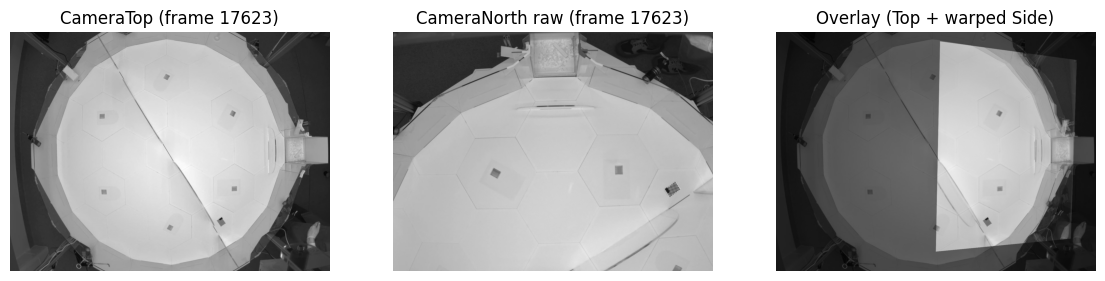

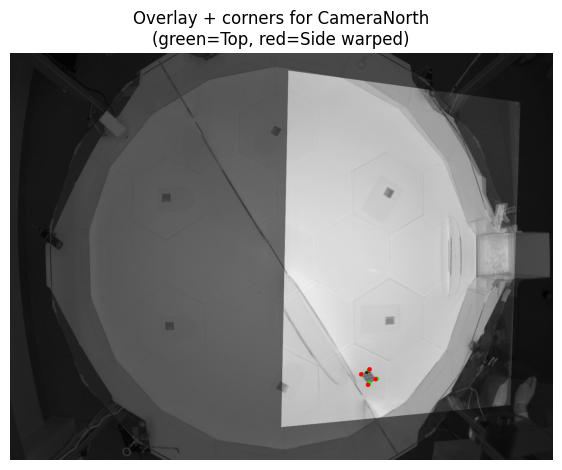


CameraSouth: shared frame not available; using fallback frame 10036


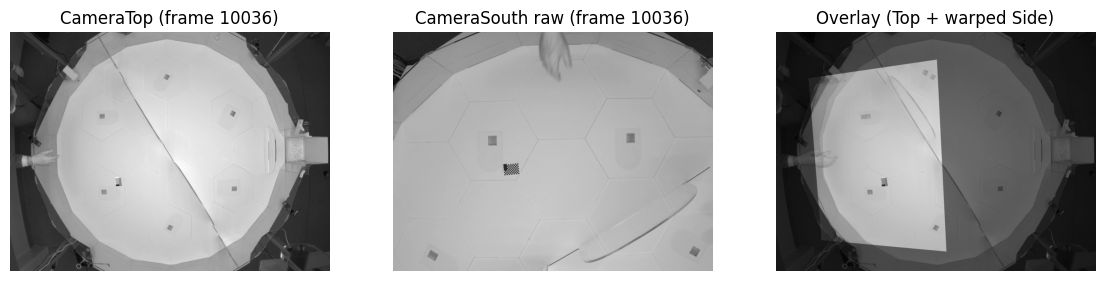

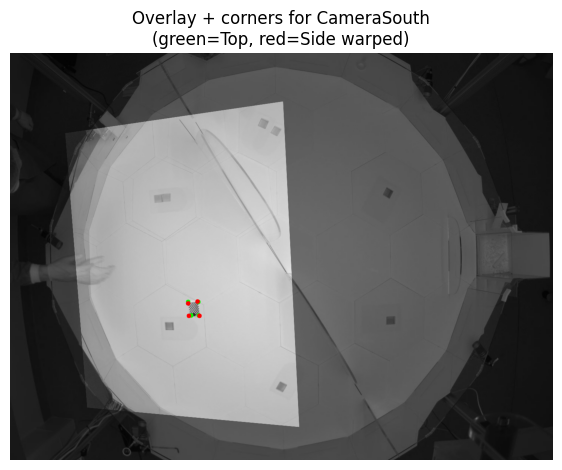

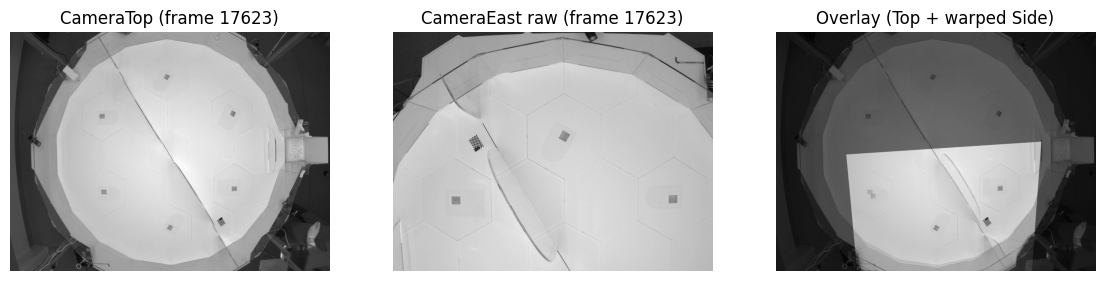

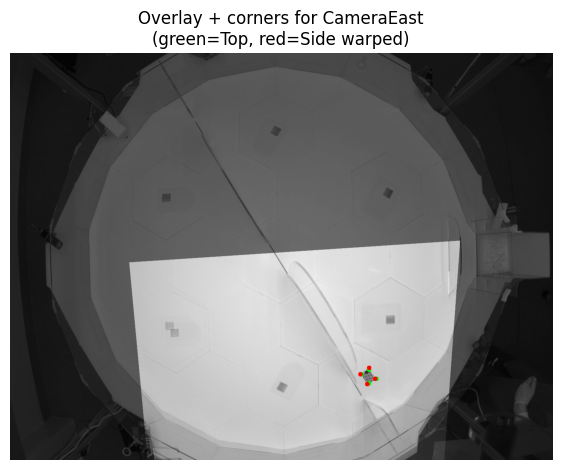


CameraWest: shared frame not available; using fallback frame 7830


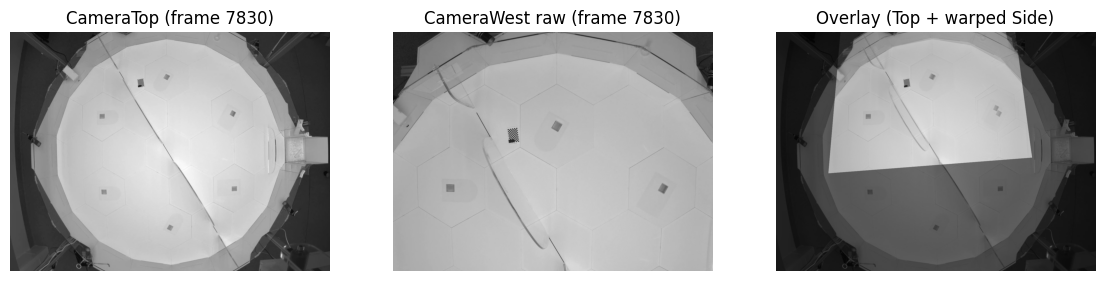

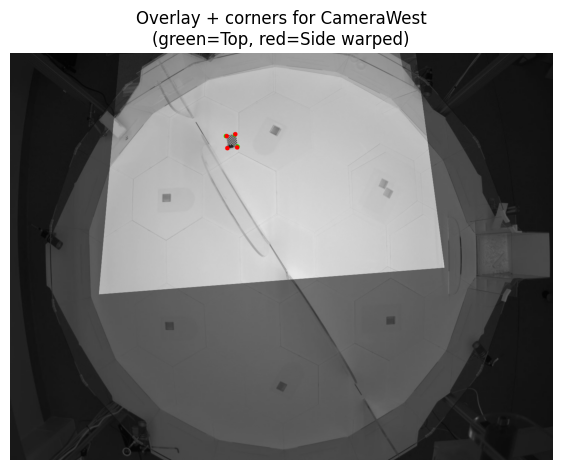


Skipping CameraNest: missing correspondence keys.


In [ ]:

rng = np.random.default_rng(0) # seed

# get all frames with card from all cameras
all_frames = np.concatenate([z_corr[f"{cam}__frames"] for cam in side_cameras if f"{cam}__frames" in z_corr])
all_frames = np.unique(all_frames.astype(int)) # delete duplicates
if all_frames.size == 0: # sanity check
    raise RuntimeError("No matched frames found in the correspondences file.")
frame_idx = int(rng.choice(all_frames))
print("Using shared random frame_idx:", frame_idx)

for camera_side in side_cameras:
    frames_key = f"{camera_side}__frames"
    top_pts_key = f"{camera_side}__top_pts"
    side_pts_key = f"{camera_side}__side_pts"
    H_key = f"{camera_side}__H_top_to_side"
    if frames_key not in z_corr or top_pts_key not in z_corr or side_pts_key not in z_corr:
        print(f"\nSkipping {camera_side}: missing correspondence keys.") # its just that the card is never in all cameras at once so this will always happen
        continue
    if H_key not in z_H:
        print(f"\nSkipping {camera_side}: missing homography key {H_key}.") # should not happen
        continue
    frames = z_corr[frames_key].astype(int)
    # Use the shared frame if available; otherwise fall back to a random frame for that camera
    if frame_idx in set(frames.tolist()):
        use_frame = frame_idx
    else:
        if frames.size == 0:
            print(f"\nSkipping {camera_side}: no frames.")
            continue
        use_frame = int(rng.choice(frames)) # choose again
        print(f"\n{camera_side}: shared frame not available; using fallback frame {use_frame}")

    # Read video frames
    video_side = build_video_path(raw_video_root, arena, experiment, session, chunk, camera_side)
    if not video_side.exists():
        print(f"\nSkipping {camera_side}: video not found: {video_side}")
        continue
    top_bgr = read_frame(video_top, use_frame)
    side_bgr = read_frame(video_side, use_frame)
    # Warp side into top coords and overlay
    H_top_to_side = z_H[H_key]
    overlay_rgb, warped_side_rgb, top_rgb, side_rgb, H_side_to_top = overlay_side_on_top(
        top_bgr, side_bgr, H_top_to_side, alpha=alpha
    )
    show_triptych(top_rgb, side_rgb, overlay_rgb, camera_side, use_frame)
    # Draw corners for this frame
    i = int(np.where(frames == use_frame)[0][0])
    top4 = z_corr[top_pts_key][i].astype(np.float32)   # (4,2)
    side4 = z_corr[side_pts_key][i].astype(np.float32) # (4,2)
    side4_warped = cv2.perspectiveTransform(side4[None, :, :], H_side_to_top)[0]
    viz = draw_corner_viz(overlay_rgb, top4, side4_warped)
    show_corner_overlay(viz, camera_side)

Loaded correspondences: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/mapping_top_to_sides_minScore0.85.npz
Loaded homographies: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/homographies_top_to_sides_ransac_thresh5.0px.npz
Example H keys: ['CameraNorth__H_top_to_side', 'CameraSouth__H_top_to_side', 'CameraEast__H_top_to_side', 'CameraWest__H_top_to_side']
Top video: /Volumes/aeon/aeon/data/raw/AEON3/abcEphysPilot01/2026-04-14T141851Z_calibrateBeforeAprilExperiments/CameraTop/CameraTop_2026-04-14T14-00-00.avi | exists: True
Using frame_idx: 17447


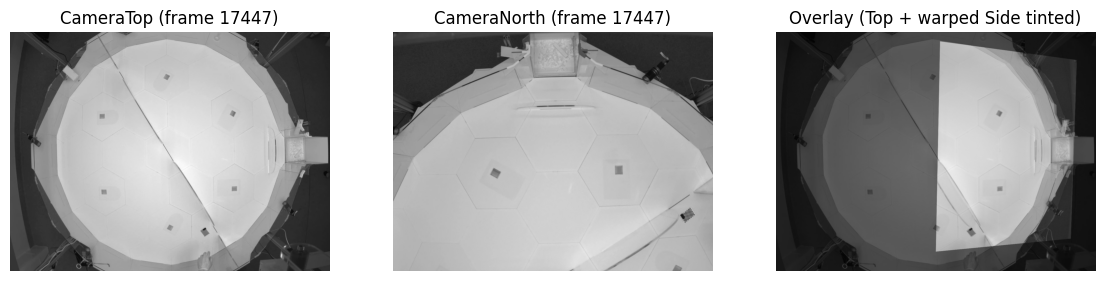

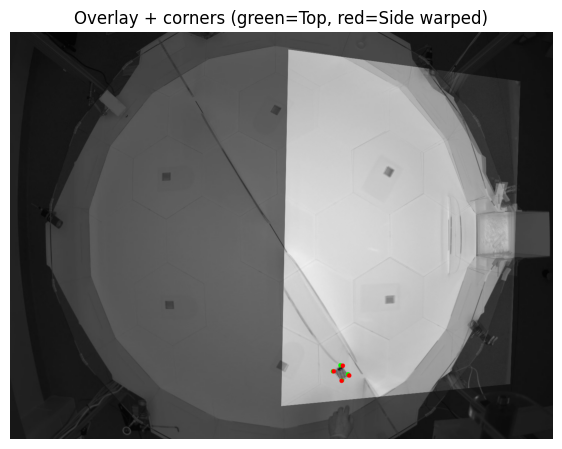

In [ ]:

corr_npz = OUT_DIR / "mapping_top_to_sides_minScore0.85.npz"
H_npz = next(OUT_DIR.glob("homographies_top_to_sides_ransac_thresh*.npz"))  # pick the one you saved
z_corr = np.load(corr_npz)
z_H = np.load(H_npz)
print("Loaded correspondences:", corr_npz)
print("Loaded homographies:", H_npz)
print("Example H keys:", [k for k in z_H.keys()][:5])

raw_video_root = Path("/Volumes/aeon/aeon/data/raw")  # on ceph : connect to server with SWC VPN, /aeon folder

def build_video_path(camera: str) -> Path:
    return raw_video_root / arena / experiment / session / camera / f"{camera}_{chunk}.avi"
video_top = build_video_path("CameraTop")
print("Top video:", video_top, "| exists:", video_top.exists())

# Choose camera for Side and adjust transparency and tint
camera_side = "CameraNorth"   # try: CameraSouth/East/West/Nest
alpha = 0.55                  # blending: 0=only top, 1=only warped side

# Pick a matched frame -> guarantees card present in both views
frames = z_corr[f"{camera_side}__frames"]
if len(frames) == 0:
    raise RuntimeError(f"No matched frames saved for {camera_side}.")

# Choose frame
# frame_idx = int(frames[len(frames) // 2])  # choose middle frame
rng = np.random.default_rng(0)  # seed
frame_idx = int(rng.choice(frames))
print("Using frame_idx:", frame_idx)

# Load frames
video_side = build_video_path(camera_side)
top_bgr = read_frame(video_top, frame_idx)
side_bgr = read_frame(video_side, frame_idx)

top_rgb = bgr_to_rgb(top_bgr)
side_rgb = bgr_to_rgb(side_bgr)

# Load H_top_to_side and invert it
H_top_to_side = z_H[f"{camera_side}__H_top_to_side"]
H_side_to_top = np.linalg.inv(H_top_to_side) # it works both ways :) so we can invert it to get the side -> top translation

# Warp side -> top canvas size
top_h, top_w = top_rgb.shape[:2]
warped_side_bgr = cv2.warpPerspective(side_bgr, H_side_to_top, (top_w, top_h))
warped_side_rgb = bgr_to_rgb(warped_side_bgr)

# Alpha blend
overlay = cv2.addWeighted(top_rgb, 1 - alpha, warped_side_rgb, alpha, 0)

# Display
plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.title(f"CameraTop (frame {frame_idx})")
plt.imshow(top_rgb)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title(f"{camera_side} (frame {frame_idx})")
plt.imshow(side_rgb)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay (Top + warped Side tinted)")
plt.imshow(overlay)
plt.axis("off")
plt.show()

# Add card corners
top_pts = z_corr[f"{camera_side}__top_pts"]      # (N,4,2)
side_pts = z_corr[f"{camera_side}__side_pts"]    # (N,4,2)

# Find which row corresponds to frame_idx
i = int(np.where(frames == frame_idx)[0][0])
top4 = top_pts[i].astype(np.float32)   # (4,2)
side4 = side_pts[i].astype(np.float32) # (4,2)

# Warp side points into top coords using H_side_to_top
side4_h = cv2.perspectiveTransform(side4[None, :, :], H_side_to_top)[0]

viz = overlay.copy()
for (x, y) in top4:
    cv2.circle(viz, (int(x), int(y)), 6, (0, 255, 0), -1)     # green: top corners
for (x, y) in side4_h:
    cv2.circle(viz, (int(x), int(y)), 6, (255, 0, 0), -1)     # red: warped side corners

plt.figure(figsize=(7, 6))
plt.title("Overlay + corners (green=Top, red=Side warped)")
plt.imshow(viz)
plt.axis("off")
plt.show()